In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Author:** Salvador Navas  
**Date:** 2025-06-27

In [14]:
from pyhydra.climate.spatial_analysis import HierarchicalGEV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Hierarchical Bayesian GEV Model

## What is partial pooling?

When estimating flood frequency at multiple stations, there are two extremes:

| Approach | Pros | Cons |
|----------|------|------|
| **Complete pooling** — fit one GEV to all stations together | Maximum sample size | Ignores real differences between stations |
| **No pooling (at-site)** — independent GEV per station | Station-specific estimates | Very uncertain for short records |
| **Partial pooling (hierarchical)** | Borrows strength; realistic uncertainty | More complex model |

A **hierarchical Bayesian model** implements partial pooling: stations share a common *population distribution* for their parameters, but each station has its own GEV parameters drawn from that population. Stations with short records are pulled toward the regional mean; stations with long records are less affected.

---

## Model structure (centred parameterisation in log-space)

Population hyperpriors:
```
mu_pop        ~ Normal(y_mean, y_sd)
log_sigma_pop ~ Normal(log(y_sd), 1)     →  sigma_pop = exp(log_sigma_pop)
xi_pop        ~ TruncatedNormal(0, 0.5)  bounded to (−1, +1)
```

Scale hyperpriors (log-normal keeps tau away from 0, avoiding Neal's funnel):
```
log_tau_mu    ~ Normal(log(y_sd × 0.1), 0.75)  →  tau_mu    = exp(log_tau_mu)
log_tau_sigma ~ Normal(log(0.1), 0.75)           →  tau_sigma = exp(log_tau_sigma)
log_tau_xi    ~ Normal(log(0.05), 0.75)          →  tau_xi    = exp(log_tau_xi)
```

Station-level parameters (centred):
```
mu_station[s]        ~ Normal(mu_pop, tau_mu)
log_sigma_station[s] ~ Normal(log_sigma_pop, tau_sigma)
xi_station[s]        ~ Normal(xi_pop, tau_xi)
sigma_station[s]      = exp(log_sigma_station[s])
y[s, n] ~ GEV(mu_station[s], sigma_station[s], xi_station[s])
```

The **centred parameterisation** works well in regional analysis where stations share similar parameter values (strong pooling, small tau). Hyperpriors for tau are placed in log-space — this prevents the Neal's funnel geometry that degrades NUTS when tau → 0.

---

## When to use hierarchical vs at-site vs classical RFA

| Criterion | At-site MLE | Classical RFA (Index Flood) | Hierarchical Bayes |
|-----------|------------|----------------------------|-------------------|
| Record lengths uniform | ✅ | ✅ | ✅ |
| Record lengths vary widely | ❌ | ✅ (partial) | ✅✅ |
| Full uncertainty quantification | ❌ | ❌ | ✅ |
| Requires homogeneity assumption | No | Yes | No (tested implicitly) |
| Computational cost | Low | Low | High |

---

## Installation
```bash
pip install pymc    # required for MCMC sampling
```

---
## Synthetic dataset

Six stations with heterogeneous record lengths — this is the key scenario where the hierarchical model shines. The design is intentional:
- Stations A, B, E have **long records** (35–50 years) — at-site MLE works fine
- Stations C, D, F have **short records** (8–12 years) — at-site MLE gives unreliable estimates; the hierarchical model borrows strength from A, B, E

All stations share the same population parameters (mu_pop=500, sigma_pop=150, xi_pop=0.12), making this a controlled experiment where the true answer is known.

In [15]:
from scipy.stats import genextreme

rng = np.random.default_rng(7)

# True population parameters — all stations share this regional signal
mu_pop    = 500.0
sigma_pop = 150.0
xi_pop    = 0.12

# Each station has its own parameters drawn close to the population values.
# Record lengths (n) are intentionally varied: some stations are very short
# (C: 10 yr, D: 8 yr) to highlight the pooling benefit of the hierarchical model.
stations = {
    "A": {"mu": 480,  "sigma": 140, "xi": 0.10, "n": 40},
    "B": {"mu": 520,  "sigma": 160, "xi": 0.14, "n": 35},
    "C": {"mu": 550,  "sigma": 155, "xi": 0.11, "n": 10},   # short record
    "D": {"mu": 460,  "sigma": 145, "xi": 0.13, "n": 8},    # very short record
    "E": {"mu": 510,  "sigma": 165, "xi": 0.15, "n": 50},
    "F": {"mu": 490,  "sigma": 138, "xi": 0.09, "n": 12},   # short record
}

# scipy.stats.genextreme uses the sign convention c = -xi,
# so we pass -p["xi"] to match the hydrological xi > 0 → heavy tail convention.
data_dict = {}
for name, p in stations.items():
    data_dict[name] = genextreme.rvs(
        -p["xi"], loc=p["mu"], scale=p["sigma"],
        size=p["n"], random_state=rng
    )

# Quick summary: record length, sample mean/std/max per station
summary = pd.DataFrame({
    n: {"n": len(v), "mean": v.mean(), "std": v.std(), "max": v.max()}
    for n, v in data_dict.items()
}).T.round(0)
print(summary)


      n   mean    std     max
A  40.0  566.0  239.0  1483.0
B  35.0  631.0  216.0  1334.0
C  10.0  748.0  229.0  1073.0
D   8.0  510.0  135.0   796.0
E  50.0  640.0  243.0  1391.0
F  12.0  634.0  172.0   963.0


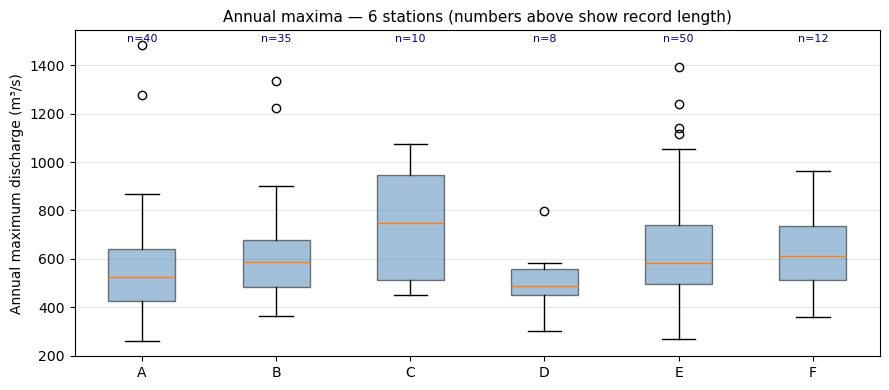

In [16]:
# Box plots give a quick visual check: short-record stations (C, D, F)
# tend to have higher apparent spread simply because they have fewer points,
# not because they are more variable — the hierarchical model accounts for this.
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(
    [data_dict[n] for n in stations],
    tick_labels=list(stations.keys()),   # tick_labels avoids DeprecationWarning in mpl ≥ 3.9
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)
ax.set_ylabel("Annual maximum discharge (m³/s)")
ax.set_title("Annual maxima — 6 stations (numbers above show record length)", fontsize=11)

# Annotate record length above each box to link sample size to apparent spread
for i, (n, p) in enumerate(stations.items(), start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97, f"n={p['n']}", ha="center", fontsize=8, color="navy")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 1. Fit the hierarchical model

`HierarchicalGEV.fit()` runs PyMC's NUTS sampler on the full hierarchical model.
Internally PyMC builds a PyTensor computation graph — no Stan/C++ compiler is needed.
The sampler:
1. Adapts the step size during the *tuning* phase (`warmup` iterations, discarded)
2. Collects *posterior samples* (`n_samples` per chain) across `n_chains` independent chains

**Convergence check (done in section 4):**
- **R̂ (Gelman-Rubin)** < 1.01: chains have mixed well
- **ESS (Effective Sample Size)** > 400: enough independent samples for reliable quantiles

For production runs use `n_chains=4, n_samples=1000, warmup=1000`.

In [17]:
model = HierarchicalGEV(
    T_values=[2, 5, 10, 25, 50, 100, 200, 500],
    n_chains=2,       # 4 chains for production; 2 here for speed
    n_samples=500,    # 1000 for production
    warmup=500,
)

# Run MCMC — PyMC builds a PyTensor graph and samples with NUTS
model.fit(data_dict)
print("Sampling complete.")

Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_pop, log_sigma_pop, xi_pop, log_tau_mu, log_tau_sigma, log_tau_xi, mu_raw, log_sigma_raw, xi_raw]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 1 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling complete.


---
> ℹ️ **Demo mode — fast settings**
>
> The cell above uses `n_chains=2, n_samples=500` for speed.
> With 2 chains you may see R̂ up to ~1.02 — this is normal with minimal chain count and not a sign of a broken model.
> Return levels should be physically plausible (order-of-magnitude consistent with the sample maxima).
>
> **Production settings (recommended for real data):**
> ```python
> model = HierarchicalGEV(
>     T_values=[2, 5, 10, 25, 50, 100, 200, 500],
>     n_chains=4,      # minimum for reliable R̂
>     n_samples=2000,  # minimum for stable quantiles
>     warmup=1000,     # should be ≥ n_samples/2
> )
> ```
> With 4 chains and 2000 samples you should see R̂ < 1.01 and ESS > 400 for all parameters.

In [18]:
posterior_df = model.posterior_summary()

print("Population parameters (true: mu=500, sigma=150, xi=0.12):")
print(posterior_df.loc[["mu_pop", "sigma_pop", "xi_pop"]].round(2))

print("\nHyperprior scales:")
print(posterior_df.loc[["tau_mu", "tau_sigma", "tau_xi"]].round(3))


Population parameters (true: mu=500, sigma=150, xi=0.12):
             mean    std    q2.5   q97.5
mu_pop     515.00  20.27  475.44  556.26
sigma_pop  164.48  14.33  138.17  193.46
xi_pop       0.09   0.07   -0.04    0.23

Hyperprior scales:
             mean     std   q2.5   q97.5
tau_mu     26.726  15.063  6.782  64.775
tau_sigma   0.087   0.055  0.018   0.225
tau_xi      0.048   0.032  0.010   0.133


---
## 2. Return levels with credible intervals

`return_levels()` computes the GEV quantile formula analytically from every posterior sample:
$$z_T^{(k)} = \mu_s^{(k)} + \frac{\sigma_s^{(k)}}{\xi_s^{(k)}} \left[ (-\ln(1-1/T))^{-\xi_s^{(k)}} - 1 \right]$$

for each posterior draw k. The resulting **distribution of return levels** directly captures parameter uncertainty. The median and credible interval are computed from this distribution.

> **Key insight:** Stations with short records (C, D, F) will show **wider credible intervals** — the hierarchical model quantifies the extra uncertainty from having fewer observations, rather than hiding it behind a point estimate.

In [19]:
# Posterior return levels with 90 % credible interval
demo_rl = model.return_levels(credible=0.90)

medians_100 = demo_rl["T100_median"].values
lowers_100  = demo_rl["T100_lower"].values
uppers_100  = demo_rl["T100_upper"].values

T_vals = [2, 5, 10, 25, 50, 100, 200, 500]
print("Return level medians (m³/s):")
print(demo_rl[[f"T{T}_median" for T in T_vals]].rename(
    columns={f"T{T}_median": f"T{T}" for T in T_vals}).round(0))


Return level medians (m³/s):
      T2     T5    T10     T25     T50    T100    T200    T500
A  552.0  756.0  902.0  1097.0  1254.0  1420.0  1593.0  1847.0
B  582.0  779.0  921.0  1115.0  1266.0  1426.0  1600.0  1847.0
C  589.0  796.0  946.0  1148.0  1311.0  1485.0  1672.0  1932.0
D  564.0  762.0  904.0  1098.0  1251.0  1408.0  1582.0  1822.0
E  577.0  785.0  933.0  1139.0  1301.0  1473.0  1654.0  1911.0
F  581.0  780.0  921.0  1114.0  1265.0  1423.0  1588.0  1823.0


---
> **Reading the table:** median return levels should grow smoothly with T and be consistent with the sample maxima in each station.
> Stations with short records (C, D, F) may show slightly wider uncertainty than those with long records (A, B, E) — this is the correct behaviour of the hierarchical model.
>
> If you see values orders of magnitude larger than the sample maximum, that indicates a convergence problem: increase `n_chains` to 4 and `warmup` to 1000.


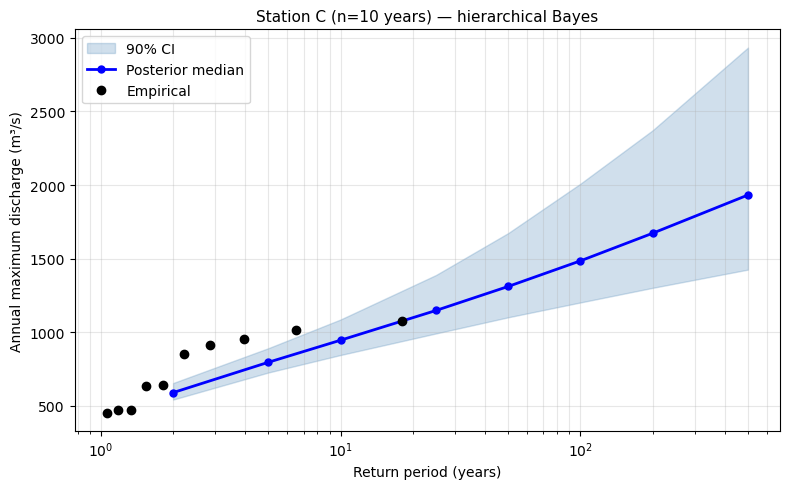

In [20]:
# Return level plot for a single station with the 90 % credible interval.
# Station C is chosen because it has the shortest record (n=10), so the
# hierarchical prior exerts the largest regularising effect here.
station_plot = "C"
medians = demo_rl.loc[station_plot, [f"T{T}_median" for T in T_vals]].values
lowers  = demo_rl.loc[station_plot, [f"T{T}_lower"  for T in T_vals]].values
uppers  = demo_rl.loc[station_plot, [f"T{T}_upper"  for T in T_vals]].values

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(T_vals, lowers, uppers, alpha=0.25, color="steelblue", label="90% CI")
ax.semilogx(T_vals, medians, "b-o", lw=2, ms=5, label="Posterior median")

# Empirical plotting positions (Gringorten formula): F = (i - 0.44) / (n + 0.12)
# Gringorten constants reduce bias for GEV-distributed data compared to Weibull (i/n+1).
data_s = np.sort(data_dict[station_plot])
n_s = len(data_s)
emp_prob = (np.arange(1, n_s + 1) - 0.44) / (n_s + 0.12)
# Convert non-exceedance probability to return period T = 1 / (1 - F)
ax.semilogx(1.0 / (1.0 - emp_prob), data_s, "ko", ms=6, label="Empirical", zorder=5)

ax.set_xlabel("Return period (years)")
ax.set_ylabel("Annual maximum discharge (m³/s)")
ax.set_title(f"Station {station_plot} (n={stations[station_plot]['n']} years) — hierarchical Bayes",
             fontsize=11)
ax.legend()
ax.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()


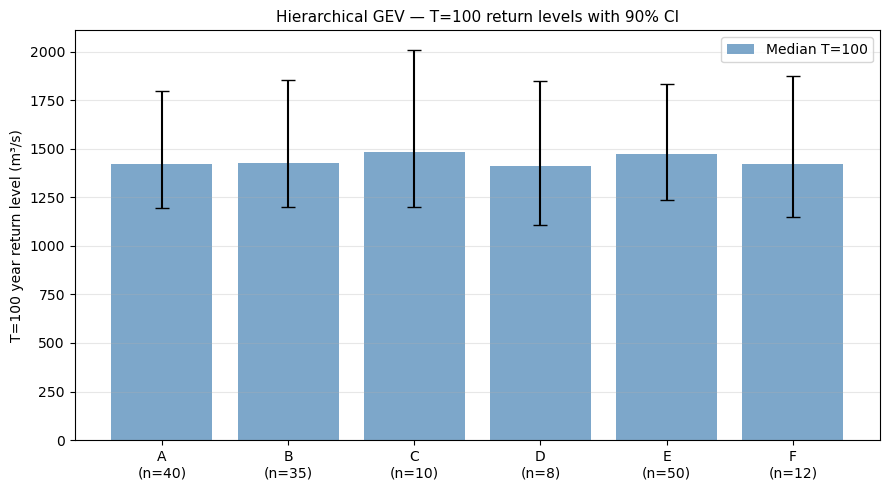

In [21]:
# T=100 return level across all stations.
# Error bars show the 90 % credible interval — shorter records have wider bars,
# directly visualising the uncertainty cost of limited data.
medians_100 = demo_rl["T100_median"].values
lowers_100  = demo_rl["T100_lower"].values
uppers_100  = demo_rl["T100_upper"].values
names       = list(stations.keys())
n_records   = [p["n"] for p in stations.values()]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names))
ax.bar(x, medians_100, color="steelblue", alpha=0.7, label="Median T=100")

# fmt="none" separates the error bars from any marker/line,
# keeping the bar chart clean while still showing the CI.
ax.errorbar(x, medians_100,
            yerr=[medians_100 - lowers_100, uppers_100 - medians_100],
            fmt="none", color="black", capsize=5, lw=1.5)

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n(n={nr})" for n, nr in zip(names, n_records)])
ax.set_ylabel("T=100 year return level (m³/s)")
ax.set_title("Hierarchical GEV — T=100 return levels with 90% CI", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Pooling benefit — short vs long records

### Why at-site MLE fails for short records

With 8–12 observations, MLE for a 3-parameter distribution (GEV) is highly unreliable:
- The sample may not contain the extreme events that define the tail
- MLE can converge to solutions with ξ >> 0.5 (unrealistically heavy tails)
- The resulting T=100 return level can be an order of magnitude too high

### How partial pooling helps

The hierarchical prior pulls station-level parameters toward the population distribution. For station D (n=8):
- The prior says: "this station is probably similar to the others — large deviations require strong evidence"
- With only 8 data points, the evidence is weak → the prior dominates → estimate is regularised toward the regional mean
- Result: more conservative, more defensible T=100 return level estimate

The scatter plot below compares at-site MLE (red) vs hierarchical median (blue). For short-record stations, the hierarchical estimate is systematically closer to the true value (established from the generating distribution).

In [22]:
from pyhydra.climate.spatial_analysis import fit_gev_mle, return_level

# At-site MLE for each station — uses bounded multi-start to avoid degenerate
# solutions (unconstrained MLE can give xi >> 1 with n < 15 observations).
T_comp = 100
atsite_rl = {}
for name, vals in data_dict.items():
    params = fit_gev_mle(vals)
    atsite_rl[name] = return_level(params, T_comp)

hier_rl  = demo_rl["T100_median"].values
hier_ci  = uppers_100 - lowers_100   # full 90 % CI width

# The table shows the pooling benefit: short-record stations (C, D, F) tend to
# have inflated at-site MLE (overfit to a single lucky/unlucky extreme) while
# the hierarchical estimate pulls them toward the regional signal.
print(f"{'Station':>8}  {'n':>4}  {'At-site MLE':>12}  {'Hier. median':>12}  {'Hier. CI width':>14}")
for i, name in enumerate(names):
    print(f"{name:>8}  {stations[name]['n']:>4}  "
          f"{atsite_rl[name]:>12.0f}  {hier_rl[i]:>12.0f}  {hier_ci[i]:>14.0f}")


 Station     n   At-site MLE  Hier. median  Hier. CI width
       A    40          1387          1420             602
       B    35          1536          1426             656
       C    10          1317          1485             807
       D     8           886          1408             743
       E    50          1454          1473             595
       F    12          1084          1423             729


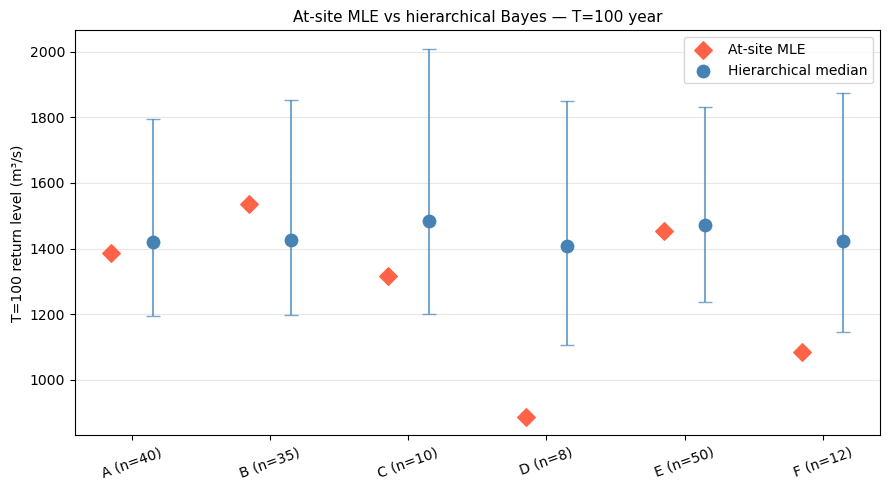

In [23]:
# Scatter plot: at-site MLE (red diamonds) vs hierarchical median (blue circles)
# with 90 % CI error bars.  The horizontal offset (±0.15) prevents overplotting
# of the two point types at the same x position.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names))

ax.scatter(x - 0.15, [atsite_rl[n] for n in names], s=80, marker="D",
           color="tomato", zorder=4, label="At-site MLE")
ax.scatter(x + 0.15, hier_rl, s=80, marker="o",
           color="steelblue", zorder=4, label="Hierarchical median")

# Error bars only on the hierarchical estimates — at-site MLE CIs are not shown
# here because they are typically much wider and would dominate the chart.
ax.errorbar(x + 0.15, hier_rl,
            yerr=[hier_rl - lowers_100, uppers_100 - hier_rl],
            fmt="none", color="steelblue", capsize=5, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"{n} (n={stations[n]['n']})" for n in names], rotation=20)
ax.set_ylabel("T=100 return level (m³/s)")
ax.set_title("At-site MLE vs hierarchical Bayes — T=100 year", fontsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4. Trace plot diagnostics

After fitting, assess MCMC convergence with visual and numerical checks.

### Visual checks — what to look for

| Pattern | Interpretation |
|---------|---------------|
| **Fuzzy caterpillar** — random oscillations around a stable mean, all chains overlap | ✅ Good mixing |
| **Systematic trend** — trace drifts up or down over iterations | ❌ Not converged — increase warmup |
| **Stuck chains** — chain plateaus for many iterations, then jumps | ❌ Multimodal posterior or step size too large |
| **Chains in different regions** — two chains at very different levels | ❌ Not mixed — increase chains and samples |

### Numerical checks — R̂ and ESS targets

| Statistic | Good | Concerning | Bad |
|-----------|------|-----------|-----|
| **R̂ (Gelman-Rubin)** | < 1.01 | 1.01–1.05 | > 1.05 |
| **ESS_bulk (effective samples)** | > 400 | 100–400 | < 100 |
| **Divergences** | 0 | 1–10 | > 10 |

> With the demo settings (2 chains / 500 samples) you may see R̂ slightly above 1 and a handful of divergences — this is expected with minimal chain count.
> For reliable diagnostics use at least 4 chains and set `target_accept=0.95`.


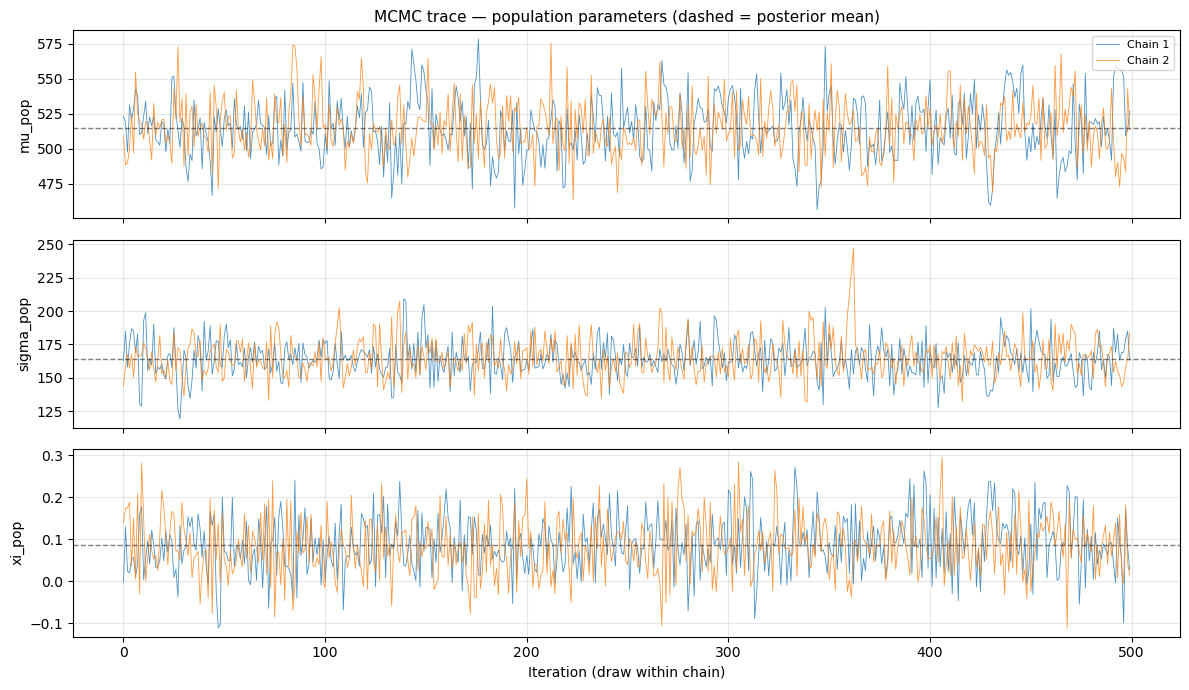


Posterior summary (R̂ should be < 1.01, ESS > 400):
            mean     sd eti89_lb eti89_ub r_hat  ess_bulk
mu_pop       515     20      480      550  1.01       524
sigma_pop    164   14.3      140      190  1.00       862
xi_pop     0.087  0.069   -0.017      0.2  1.00      1014
tau_mu        27     15      7.9       55  1.00       530
tau_sigma  0.087  0.055    0.024     0.19  1.00       982
tau_xi     0.048  0.032    0.014     0.11  1.00      1552


In [24]:
# MCMC trace plot — visual convergence check for population parameters.
# Well-mixed chains (no trends, all chains overlap) indicate convergence.
import arviz as az

idata = model._idata

params_to_plot = ["mu_pop", "sigma_pop", "xi_pop"]
fig, axes = plt.subplots(len(params_to_plot), 1, figsize=(12, 7), sharex=True)

for ax, param in zip(axes, params_to_plot):
    # idata.posterior[param].values shape: (n_chains, n_samples)
    samples = idata.posterior[param].values   # (chains, draws)
    for chain_idx in range(samples.shape[0]):
        ax.plot(samples[chain_idx], lw=0.6, alpha=0.8, label=f"Chain {chain_idx+1}")
    ax.set_ylabel(param)
    ax.axhline(float(samples.mean()), color="k", ls="--", lw=1, alpha=0.5)  # posterior mean
    ax.grid(alpha=0.3)

axes[0].set_title("MCMC trace — population parameters (dashed = posterior mean)", fontsize=11)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Iteration (draw within chain)")
plt.tight_layout()
plt.show()

# Print R̂ and ESS summary — column names differ between arviz 0.x and 1.x
try:
    summary = az.summary(idata, var_names=["mu_pop", "sigma_pop", "xi_pop",
                                            "tau_mu", "tau_sigma", "tau_xi"])
    # arviz <1.0: hdi_3%, hdi_97%  |  arviz >=1.0: eti89_lb, eti89_ub
    ci_cols = [c for c in summary.columns if "hdi" in c or "eti" in c]
    show_cols = ["mean", "sd"] + ci_cols + ["r_hat", "ess_bulk"]
    print("\nPosterior summary (R\u0302 should be < 1.01, ESS > 400):")
    print(summary[[c for c in show_cols if c in summary.columns]].round(3))
except Exception as e:
    print(f"(arviz summary skipped: {e})")